# MetaLore-ISAC — Entity Demo

Demonstrates the `ISACVehicle` entity: a mobile device with a single RF chain that operates in either **sensing mode** (`a_k = 1`, orange) or **communication mode** (`a_k = 0`, teal).

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from IPython import display as ipd

from metalore.core.entities import ISACVehicle
from metalore.scenarios import SingleCellEnv
from metalore.config import isac_vehicle_config

print('MetaLore-ISAC imported successfully!')

MetaLore-ISAC imported successfully!


## Create & Reset Environment

In [2]:
env = SingleCellEnv(config=isac_vehicle_config())
obs, info = env.reset()

print(f'Base Stations : {env.num_bs}')
print(f'ISAC vehicles : {env.num_isac_vehicles}')
print(f'Sensors       : {env.num_sensors}')
print(f'Area          : {env.width} x {env.height} m')
print(f'Max Steps     : {env.EP_MAX_TIME}')
print(f'Action Space  : {env.action_space}')
print(f'Obs Space     : {env.observation_space}')
print(f'Initial obs   : {obs}')

Base Stations : 1
ISAC vehicles : 40
Sensors       : 10
Area          : 200.0 x 200.0 m
Max Steps     : 200
Action Space  : Box(0.0, 1.0, (2,), float32)
Obs Space     : Box(0.0, 10000.0, (2,), float32)
Initial obs   : [0. 0.]


## Run Episode with Rendering

The action vector is `[bw_split, comp_split, mode_v0, ..., mode_vN]`.  
Vehicle modes (≥ 0.5 → sensing, < 0.5 → comm) are passed through the action so the handler sets `sensing_mode` each step.

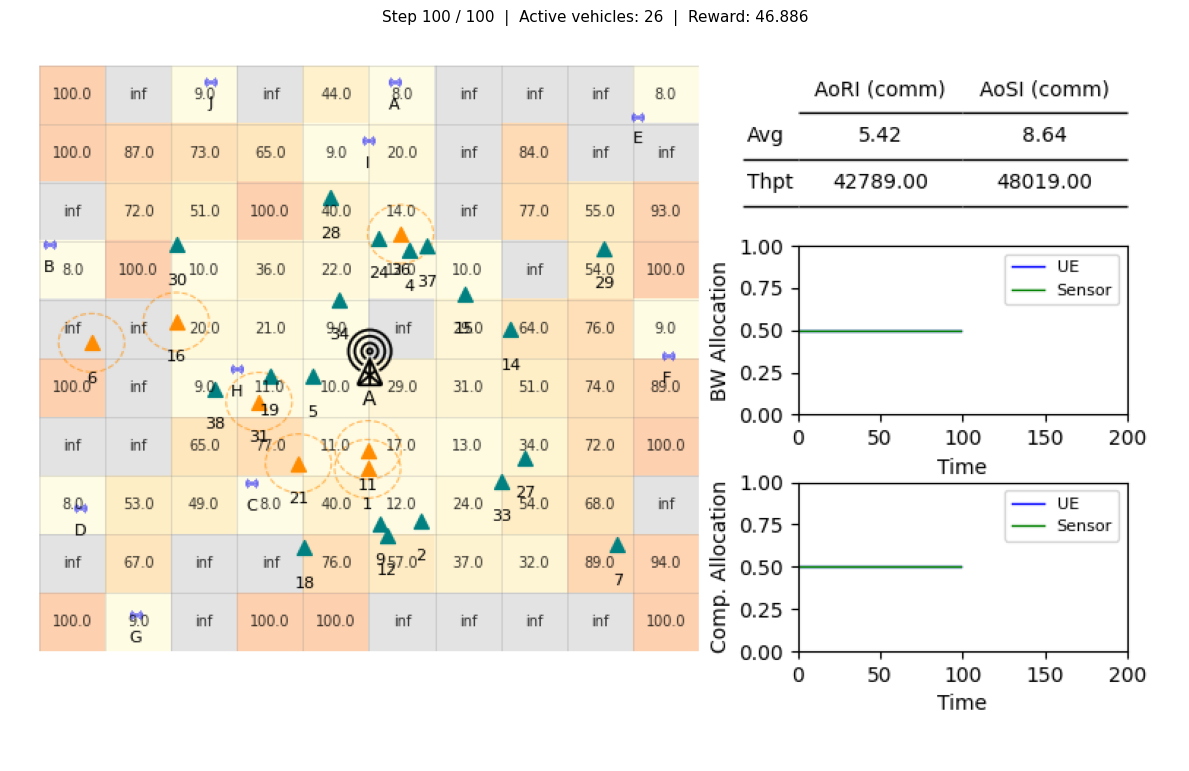


Steps completed : 100
Total reward    : 7574.8907


In [5]:
N_STEPS = 100
rewards = []
env.reset()

for step in range(N_STEPS):
    action = [0.5, 0.5]
    obs, reward, terminated, truncated, info = env.step(action)
    rewards.append(reward)

    if terminated or truncated:
        print(f'Episode ended at step {step+1}')
        break

    # Animate during simulation
    ipd.clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(env.render())
    ax.set_title(
        f'Step {step + 1} / {N_STEPS}  |  '
        f'Active vehicles: {len(env.active_isac_vehicles)}  |  '
        f'Reward: {reward:.3f}',
        fontsize=11,
    )
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    plt.close()

print()
print(f'Steps completed : {len(rewards)}')
print(f'Total reward    : {sum(rewards):.4f}')

## Job Log (completed jobs)

In [ ]:
import pandas as pd
from IPython.display import display

job_df = env.job_tracker.to_dataframe()
print(f'Completed jobs: {len(job_df)}')
display(job_df)

In [ ]:
job_df.to_csv('job_log.csv', index=False)
print('Saved to job_log.csv')

## AoI Summary (UE jobs only)

In [ ]:
ue_df = job_df[job_df['entity_type'] == 'ISAC']

for col, label in [('aori', 'AoRI'), ('aosi', 'AoSI'), ('aoi', 'AoI')]:
    s = ue_df[col].dropna()
    if not s.empty:
        print(f'{label:5s}  mean={s.mean():.2f}  max={s.max():.0f}  min={s.min():.0f}')

## Episode Metrics Summary

In [ ]:
ep = env.metrics.finalize(env.job_tracker)

print(f"Jobs generated  : {ep['jobs_generated']}")
print(f"Jobs transmitted: {ep['jobs_transmitted']}")
print(f"Jobs processed  : {ep['jobs_processed']}")
print(f"Completion rate : {ep['job_completion_rate']:.1%}")
print(f"Total reward    : {ep['total_reward']:.4f}")
print()
print(f"mean AoRI       : {ep['mean_aori']}")
print(f"mean AoSI       : {ep['mean_aosi']}")

## Zone Age Map

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
zm = env.zone_map
ages = zm.aozi(env.time)

# Left: spatial view — AoZ heatmap with vehicles and sensors overlaid
ax = axes[0]
im = ax.imshow(
    ages.T,
    extent=[0, env.width, 0, env.height],
    origin='lower',
    cmap='YlOrRd',
    aspect='auto',
    vmin=0,
    vmax=N_STEPS,
)
for i in range(zm.num_zones_x + 1):
    ax.axvline(i * zm.zone_w, color='gray', linewidth=0.4, alpha=0.4)
for j in range(zm.num_zones_y + 1):
    ax.axhline(j * zm.zone_h, color='gray', linewidth=0.4, alpha=0.4)
for i in range(zm.num_zones_x):
    for j in range(zm.num_zones_y):
        cx, cy = zm.zone_center(i, j)
        ax.text(cx, cy, str(ages[i, j]), ha='center', va='center', fontsize=7, color='black')

for sensor in env.sensors.values():
    ax.scatter(sensor.x, sensor.y, s=60, marker='s', color='blue', zorder=2, alpha=0.6)
for vehicle in env.isac_vehicles.values():
    color = 'darkorange' if vehicle.sensing_mode else 'teal'
    ax.scatter(vehicle.x, vehicle.y, s=180, marker='^', color=color, zorder=3)
    ax.annotate(str(vehicle.id), xy=(vehicle.x, vehicle.y), xytext=(0, -12),
                ha='center', va='top', textcoords='offset points', fontsize=8)
for bs in env.stations.values():
    ax.scatter(bs.x, bs.y, s=250, marker='*', color='black', zorder=4)

plt.colorbar(im, ax=ax, label='Age of Zone (timesteps)')
ax.set_xlim(0, env.width)
ax.set_ylim(0, env.height)
ax.set_title('AoZ — End-of-Episode (spatial)')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.legend(handles=[
    mpatches.Patch(color='darkorange', label='sensing'),
    mpatches.Patch(color='teal',       label='comm'),
    mpatches.Patch(color='blue',       label='static sensor'),
], fontsize=8, loc='upper right')

# Right: pure grid view
ax2 = axes[1]
im2 = ax2.imshow(ages.T, cmap='YlOrRd', origin='lower', vmin=0, vmax=N_STEPS, aspect='equal')
for i in range(zm.num_zones_x):
    for j in range(zm.num_zones_y):
        ax2.text(i, j, str(ages[i, j]), ha='center', va='center', fontsize=9, color='black')
plt.colorbar(im2, ax=ax2, label='Age of Zone (timesteps)')
ax2.set_title(f'AoZ Grid  (avg={ages.mean():.1f}, max={ages.max()})')
ax2.set_xticks(range(zm.num_zones_x))
ax2.set_yticks(range(zm.num_zones_y))
ax2.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

## Zone Age Map & Vehicle Positions

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

zm = env.zone_map
ages = zm.aozi(env.time)

# Left: AoZ heatmap with vehicles overlaid
ax = axes[0]
im = ax.imshow(
    ages.T,
    extent=[0, env.width, 0, env.height],
    origin='lower',
    cmap='YlOrRd',
    aspect='auto',
    vmin=0,
    vmax=N_STEPS,
)
for i in range(zm.num_zones_x + 1):
    ax.axvline(i * zm.zone_w, color='gray', linewidth=0.5, alpha=0.5)
for j in range(zm.num_zones_y + 1):
    ax.axhline(j * zm.zone_h, color='gray', linewidth=0.5, alpha=0.5)
for i in range(zm.num_zones_x):
    for j in range(zm.num_zones_y):
        cx, cy = zm.zone_center(i, j)
        ax.text(cx, cy, str(ages[i, j]), ha='center', va='center', fontsize=9, color='black')

for vehicle in env.isac_vehicles.values():
    color = 'darkorange' if vehicle.sensing_mode else 'teal'
    ax.scatter(vehicle.x, vehicle.y, s=220, marker='^', color=color, zorder=3)
    ax.annotate(str(vehicle.id), xy=(vehicle.x, vehicle.y), xytext=(0, -14),
                ha='center', va='top', textcoords='offset points', fontsize=9)
    if vehicle.sensing_mode:
        ax.add_patch(mpatches.Circle((vehicle.x, vehicle.y), vehicle.sensing_range,
                                     fill=False, linestyle='--', edgecolor='darkorange', alpha=0.5))

for sensor in env.sensors.values():
    ax.scatter(sensor.x, sensor.y, s=80, marker='s', color='blue', zorder=2, alpha=0.6)
for bs in env.stations.values():
    ax.scatter(bs.x, bs.y, s=300, marker='*', color='black', zorder=4)

plt.colorbar(im, ax=ax, label='Age of Zone (timesteps)')
ax.set_xlim(0, env.width)
ax.set_ylim(0, env.height)
ax.set_title('Age of Zone — End-of-Episode State')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_aspect('equal')

# Right: AoZ as a pure heatmap grid
ax2 = axes[1]
im2 = ax2.imshow(
    ages.T,
    cmap='YlOrRd',
    origin='lower',
    vmin=0,
    vmax=N_STEPS,
    aspect='equal',
)
for i in range(zm.num_zones_x):
    for j in range(zm.num_zones_y):
        ax2.text(i, j, str(ages[i, j]), ha='center', va='center', fontsize=11, color='black')
plt.colorbar(im2, ax=ax2, label='Age of Zone (timesteps)')
ax2.set_xticks(range(zm.num_zones_x))
ax2.set_yticks(range(zm.num_zones_y))
ax2.set_xticklabels([f'col {i}' for i in range(zm.num_zones_x)], fontsize=8)
ax2.set_yticklabels([f'row {j}' for j in range(zm.num_zones_y)], fontsize=8)
ax2.set_title(f'AoZ Grid  (avg={ages.mean():.1f}, max={ages.max()})')

plt.tight_layout()
plt.show()

## Queue Evolution per Static Sensor

In [ ]:
t        = env.metrics.step_totals['time']
tx_data  = env.metrics.step_per_entity['tx_queue_jobs']
sids     = sorted(env.sensors.keys())
cmap     = plt.cm.tab10

fig, ax = plt.subplots(figsize=(14, 5))
for idx, sid in enumerate(sids):
    key = ('SENSOR', 'SENSOR', sid)
    if key in tx_data:
        ax.plot(t, tx_data[key], label=f'S{sid}', color=cmap(idx / len(sids)), linewidth=1.2, alpha=0.8)

ax.set_xlabel('Timestep')
ax.set_ylabel('TX queue length (jobs)')
ax.set_title('TX Queue Evolution per Static Sensor')
ax.legend(ncol=5, fontsize=7, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Queue Evolution per ISAC Vehicle

In [ ]:
t        = env.metrics.step_totals['time']
tx_data  = env.metrics.step_per_entity['tx_queue_jobs']
vids     = sorted(env.isac_vehicles.keys())
cmap     = plt.cm.tab20

fig, ax = plt.subplots(figsize=(14, 5))
for idx, vid in enumerate(vids):
    key = ('ISAC', 'ISAC_SENSING', vid)
    if key in tx_data:
        ax.plot(t, tx_data[key], label=f'V{vid}', color=cmap(idx / len(vids)), linewidth=1.2, alpha=0.8)

ax.set_xlabel('Timestep')
ax.set_ylabel('TX queue length (jobs)')
ax.set_title('TX Queue Evolution per ISAC Vehicle')
ax.legend(ncol=5, fontsize=7, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Processing Queue Evolution at BS

In [ ]:
t     = env.metrics.step_totals['time']
pb    = env.metrics.step_per_bs
bs_id = list(env.stations.keys())[0]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t, pb['sensor_proc_queue_jobs'][bs_id], label='Sensor queue (SENSOR + ISAC_SENSING)', color='steelblue', linewidth=1.5)
ax.plot(t, pb['ue_proc_queue_jobs'][bs_id],     label='UE queue (ISAC_COMM)',                 color='teal',       linewidth=1.5)
ax.set_xlabel('Timestep')
ax.set_ylabel('Jobs in processing queue')
ax.set_title('Processing Queue Length at BS over Time')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Cycles Processed per Timestep (per Queue)

In [ ]:
st = env.metrics.step_totals
t  = st['time']

sensor_queue_cycles = [s + i for s, i in zip(st['sensor_cycles_processed'], st['isac_sensing_cycles_processed'])]
ue_queue_cycles     = st['isac_comm_cycles_processed']

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t, sensor_queue_cycles, label='Sensor queue (SENSOR + ISAC_SENSING)', color='steelblue', linewidth=1.5)
ax.plot(t, ue_queue_cycles,     label='UE queue (ISAC_COMM)',                 color='teal',       linewidth=1.5)
ax.set_xlabel('Timestep')
ax.set_ylabel('CPU cycles processed')
ax.set_title('Cycles Processed per Timestep per Queue')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Datarates per Entity over Time

In [ ]:
t       = env.metrics.step_totals['time']
dr_data = env.metrics.step_per_entity['datarate']
vids    = sorted(env.isac_vehicles.keys())
sids    = sorted(env.sensors.keys())

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# ISAC vehicles
ax1 = axes[0]
cmap_v = plt.cm.tab20
for idx, vid in enumerate(vids):
    key = ('ISAC', 'ISAC_COMM', vid)
    if key in dr_data:
        ax1.plot(t, dr_data[key], label=f'V{vid}', color=cmap_v(idx / len(vids)), linewidth=1.0, alpha=0.8)
ax1.set_ylabel('Datarate (bps)')
ax1.set_title('ISAC Vehicle Datarates over Time')
ax1.legend(ncol=5, fontsize=7, loc='upper right')
ax1.grid(True, alpha=0.3)

# Static sensors
ax2 = axes[1]
cmap_s = plt.cm.tab10
for idx, sid in enumerate(sids):
    key = ('SENSOR', 'SENSOR', sid)
    if key in dr_data:
        ax2.plot(t, dr_data[key], label=f'S{sid}', color=cmap_s(idx / len(sids)), linewidth=1.0, alpha=0.8)
ax2.set_ylabel('Datarate (bps)')
ax2.set_xlabel('Timestep')
ax2.set_title('Static Sensor Datarates over Time')
ax2.legend(ncol=5, fontsize=7, loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Datarates per Entity per Timestep (Sensing / Comm / Sensor)

In [ ]:
t       = env.metrics.step_totals['time']
dr_data = env.metrics.step_per_entity['datarate']
vids    = sorted(env.isac_vehicles.keys())
sids    = sorted(env.sensors.keys())

# All ISAC vehicle datarates are stored under the ISAC_COMM key (metrics.py:160).
# Mode (sensing vs comm) determines which TX queue is drained, not the channel capacity.
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# --- Panel 1: ISAC vehicle datarate (channel capacity per vehicle per step) ---
ax1 = axes[0]
vehicle_rows = []
for vid in vids:
    key = ('ISAC', 'ISAC_COMM', vid)
    if key in dr_data:
        y = np.array(dr_data[key], dtype=float)
        ax1.plot(t, y, color='steelblue', linewidth=0.7, alpha=0.25)
        vehicle_rows.append(y)
if vehicle_rows:
    ax1.plot(t, np.mean(vehicle_rows, axis=0),
             color='steelblue', linewidth=2.0, label='Mean (all vehicles)')
ax1.set_ylabel('Datarate (sim-bits / step)')
ax1.set_title('ISAC Vehicle Channel Capacity per Timestep\n(same RF used for sensing and comm — mode determines which TX queue is drained)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)

# --- Panel 2: Static sensor datarate per sensor ---
ax2 = axes[1]
cmap_s = plt.cm.tab10
for idx, sid in enumerate(sids):
    key = ('SENSOR', 'SENSOR', sid)
    if key in dr_data:
        y = np.array(dr_data[key], dtype=float)
        ax2.plot(t, y, color=cmap_s(idx / len(sids)),
                 linewidth=1.2, alpha=0.85, label=f'S{sid}')
ax2.set_ylabel('Datarate (sim-bits / step)')
ax2.set_xlabel('Timestep')
ax2.set_title('Static Sensor Datarate per Timestep')
ax2.legend(ncol=5, fontsize=7, loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
from IPython.display import display

t       = env.metrics.step_totals['time']
dr_data = env.metrics.step_per_entity['datarate']
vids    = sorted(env.isac_vehicles.keys())

# metrics.py stores all ISAC vehicle datarates under the ISAC_COMM key regardless of mode.
# The mode only determines which TX queue gets drained, not the channel capacity itself.
rows = {}
for vid in vids:
    key = ('ISAC', 'ISAC_COMM', vid)
    rows[f'V{vid}'] = np.array(dr_data.get(key, [float('nan')] * len(t)))

dr_vehicle_df = pd.DataFrame(rows, index=t)
dr_vehicle_df.index.name = 'timestep'

dr_vehicle_df.to_csv('datarate_vehicles.csv')
print(f"Shape: {dr_vehicle_df.shape}  (timesteps × vehicles)")
print(f"Units: simulation-bits / step  (Shannon Mbps value used as TX capacity)")
print("Saved: datarate_vehicles.csv")
display(dr_vehicle_df.round(4))

In [ ]:
sids = sorted(env.sensors.keys())

rows_s = {}
for sid in sids:
    key = ('SENSOR', 'SENSOR', sid)
    rows_s[f'S{sid}'] = np.array(dr_data.get(key, [float('nan')] * len(t)))

dr_sensor_df = pd.DataFrame(rows_s, index=t)
dr_sensor_df.index.name = 'timestep'

dr_sensor_df.to_csv('datarate_sensors.csv')
print(f"Shape: {dr_sensor_df.shape}  (timesteps × sensors)")
print(f"Units: simulation-bits / step")
print("Saved: datarate_sensors.csv")
display(dr_sensor_df.round(4))

## Datarate Calculation — Step-by-Step Example

For a single vehicle, showing how the channel model, scheduler, and Shannon formula combine to produce the per-step datarate that drains the TX queue.

In [ ]:
import numpy as np

# Pick the first BS and first ISAC vehicle from the last episode
bs      = list(env.stations.values())[0]
vehicle = list(env.isac_vehicles.values())[0]
cfg     = env.config

# ── Step 1: distance ────────────────────────────────────────────────────────
dist_m  = np.sqrt((bs.x - vehicle.x)**2 + (bs.y - vehicle.y)**2)
dist_km = dist_m / 1000
print(f"BS position      : ({bs.x:.1f}, {bs.y:.1f}) m")
print(f"Vehicle position : ({vehicle.x:.1f}, {vehicle.y:.1f}) m")
print(f"Distance         : {dist_m:.1f} m  =  {dist_km:.4f} km")

# ── Step 2: Okumura-Hata path loss ──────────────────────────────────────────
freq  = bs.frequency   # MHz
h_bs  = bs.height      # m
h_ue  = vehicle.height # m

ch     = 0.8 + (1.1 * np.log10(freq) - 0.7) * h_ue - 1.56 * np.log10(freq)
tmp_1  = 69.55 - ch + 26.16 * np.log10(freq) - 13.82 * np.log10(h_bs)
tmp_2  = 44.9  - 6.55 * np.log10(h_bs)
pl_dB  = tmp_1 + tmp_2 * np.log10(dist_km + 1e-16)

print(f"\n── Okumura-Hata path loss ──────────────────────────────────────")
print(f"Carrier frequency: {freq} MHz")
print(f"BS height        : {h_bs} m,  vehicle height: {h_ue} m")
print(f"Correction ch    : {ch:.4f}")
print(f"tmp_1            : {tmp_1:.4f}")
print(f"tmp_2            : {tmp_2:.4f}")
print(f"Path loss        : {pl_dB:.2f} dB")

# ── Step 3: SNR ─────────────────────────────────────────────────────────────
rx_power_W = 10 ** ((bs.tx_power - pl_dB) / 10)   # dBm → W
snr        = rx_power_W / vehicle.noise

print(f"\n── SNR ─────────────────────────────────────────────────────────")
print(f"TX power         : {bs.tx_power} dBm")
print(f"Received power   : {rx_power_W:.4e} W")
print(f"Noise floor      : {vehicle.noise:.4e} W")
print(f"SNR              : {snr:.2f}  ({10*np.log10(snr):.1f} dB)")

# ── Step 4: bandwidth allocation ────────────────────────────────────────────
bw_split       = 0.2   # from the action used in the episode above
total_bw       = bs.bandwidth                          # 100 MHz
bw_isac_pool   = bw_split * total_bw                  # ISAC vehicle pool
bw_per_vehicle = bw_isac_pool / env.num_isac_vehicles  # ResourceFair: equal share

print(f"\n── Bandwidth allocation (bw_split={bw_split}) ──────────────────")
print(f"Total BS bandwidth   : {total_bw/1e6:.0f} MHz")
print(f"ISAC pool (bw_split) : {bw_isac_pool/1e6:.1f} MHz")
print(f"Vehicles in pool     : {env.num_isac_vehicles}")
print(f"Per-vehicle share    : {bw_per_vehicle/1e6:.2f} MHz")

# ── Step 5: Shannon capacity ─────────────────────────────────────────────────
datarate_Mbps = bw_per_vehicle * np.log2(1 + snr) / 1e6

print(f"\n── Shannon capacity ─────────────────────────────────────────────")
print(f"Formula  : bw × log2(1 + SNR) / 1e6")
print(f"         = {bw_per_vehicle:.0f} × log2(1 + {snr:.0f}) / 1e6")
print(f"         = {bw_per_vehicle:.0f} × {np.log2(1+snr):.4f} / 1e6")
print(f"Datarate : {datarate_Mbps:.4f} Mbps")

# ── Step 6: TX queue draining (the simulator unit quirk) ─────────────────────
# transmit() treats the Mbps value as "bits to drain per step"
bits_drained_per_step = datarate_Mbps   # NOT real Mbps — used as simulation bits/step

print(f"\n── TX queue draining ────────────────────────────────────────────")
print(f"transmit() drains {bits_drained_per_step:.4f} simulation-bits per step")
print()
for job_label, data_size in [("SENSOR job", 60.0), ("ISAC_SENSING job", 80.0), ("ISAC_COMM job", 8.0)]:
    steps = data_size / bits_drained_per_step if bits_drained_per_step > 0 else float('inf')
    print(f"  {job_label:20s}  data_size={data_size:.0f} bits  →  transmits in {steps:.2f} steps")